# Au verification: multislice vs WPM vs ODE

Thicknes sweep for Au comparing abTEM multislice, WPM, and an adaptive ODE integrator.

In [14]:
%matplotlib widget

import os
import sys
from pathlib import Path

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".4"

import abtem
import diffrax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk
from tqdm import trange
from tqdm.auto import tqdm

# add parent folder (and common src folder) to sys.path so imports can be resolved
parent = Path.cwd().parent
candidates = [parent, parent / "src"]
for p in candidates:
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from jax_multislice import (
    electron_refractive_index,
    energy2wavelength,
    wpm_step_adaptive,
    Propagator as convolve2d,
    fresnel_propagation_kernel,
)

abtem.config.set({"device": "cpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)


def beam_amplitude_normalized(psi_xy, h, k, use_fftshift=True):
    Ny, Nx = psi_xy.shape

    # normalized Fourier coefficients so that a unit plane wave has C00 = 1
    C = jnp.fft.fft2(psi_xy) / (Nx * Ny)

    if use_fftshift:
        C = jnp.fft.fftshift(C)
        cy, cx = Ny // 2, Nx // 2
        return jnp.abs(C[cy + k, cx + h])   # [h,k] beam
    else:
        # unshifted indexing: negative orders wrap around
        return jnp.abs(C[k % Ny, h % Nx])

## Crystal and beam setup

In [15]:
atoms = bulk("Au", "fcc", a=4.08, cubic=True)
coarse_unitcell_gpts = (128, 128, 2)
fine_unitcell_gpts = (128, 128, 128)
energy = 300e3
n_cells_range = range(0, 26)


## Potential generation and probe

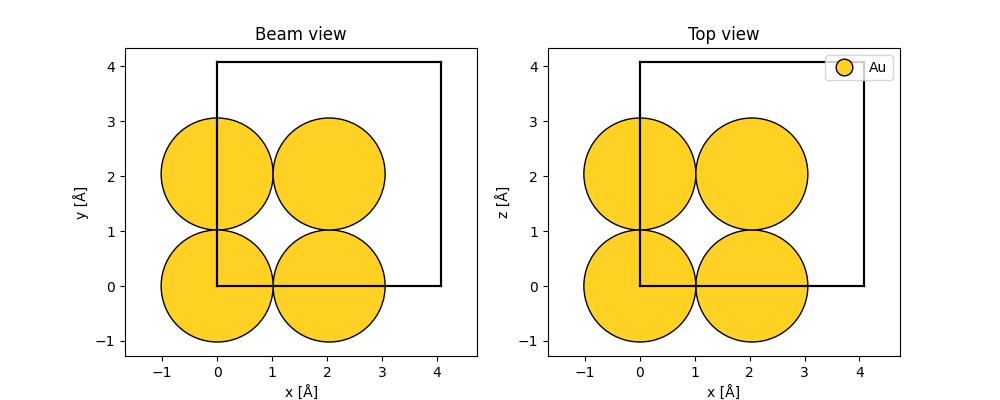

In [ ]:
n_slices_coarse = coarse_unitcell_gpts[2]
cell_thickness = atoms.get_cell()[2, 2]
slice_thickness_coarse = cell_thickness / n_slices_coarse

potential_coarse = abtem.Potential(
    atoms,
    gpts=coarse_unitcell_gpts[:2],
    slice_thickness=slice_thickness_coarse,
    projection="infinite",
)
pot_array_coarse = potential_coarse.build(lazy=False).array / slice_thickness_coarse

n_slices_fine = fine_unitcell_gpts[2]
slice_thickness_fine = cell_thickness / n_slices_fine
potential_fine = abtem.Potential(
    atoms,
    gpts=fine_unitcell_gpts[:2],
    slice_thickness=slice_thickness_fine,
    projection="finite",
)
pot_array_fine = potential_fine.build(lazy=False).array
pot_array_fine = pot_array_fine / slice_thickness_fine

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
abtem.show_atoms(atoms, ax=ax1, title="Beam view", merge=False)
abtem.show_atoms(atoms, ax=ax2, plane="xz", title="Top view", legend=True)
plt.show()

wavelength = energy2wavelength(energy)
k0 = 2 * np.pi / wavelength

probe = abtem.PlaneWave(energy=energy)
probe.grid.match(potential_coarse)
probe_array = probe.build(lazy=False).array

## WPM helper

In [17]:
def simulate_pattern_wpm(potential, probe, dz, energy, ps):
    wavefront = probe
    for i in trange(potential.shape[0], desc="WPM slices"):
        n = electron_refractive_index(potential[i], energy)
        wavefront, _, _, _ = wpm_step_adaptive(
            wavefront,
            n,
            dz,
            energy,
            ps,
            n_bins=128,
            power_spacing=2.0,
        )

    diffraction = jnp.abs(jnp.fft.fftshift(jnp.fft.fft2(wavefront)))
    return wavefront, diffraction


def simulate_pattern_fresnel_as(potential, probe, prop_kernel, dz):
    wavefront = probe
    wavefronts = []

    for i in range(potential.shape[0]):
        n = electron_refractive_index(potential[i], energy)
        phase_shift = jnp.exp(1j * 2 * jnp.pi * (n - 1) * dz / wavelength)
        wavefront = wavefront * phase_shift
        wavefront = convolve2d(wavefront, prop_kernel)
        wavefronts.append(wavefront)
    
    exit_wave = wavefront
    
    detector_wavefront = jnp.fft.fftshift(
        jnp.fft.fft2(wavefront)
    )
    diffraction_pattern = (
        jnp.square(detector_wavefront.real)
        + jnp.square(detector_wavefront.imag)
    )
    return exit_wave, diffraction_pattern



## Ground truth ODE helper

In [18]:
def make_G2(ny, nx, ps):
    fy = jnp.fft.fftfreq(ny, d=ps[0])
    fx = jnp.fft.fftfreq(nx, d=ps[1])
    Fy, Fx = jnp.meshgrid(fy, fx, indexing="ij")
    Gy = 2 * jnp.pi * Fy
    Gx = 2 * jnp.pi * Fx
    return (Gx**2 + Gy**2), Gx, Gy


def rhs_helmholtz(z, y, args):
    """
    args = (n_interp, k0, G2)
    """
    psi_hat, psi_z_hat = y
    n_interp, k0, G2 = args
    
    n_xy = n_interp.evaluate(z)
    n2_xy = n_xy**2

    psi_xy = jnp.fft.ifft2(psi_hat)
    coupling_hat = jnp.fft.fft2(n2_xy * psi_xy)
    
    psi_zz_hat = (G2 * psi_hat) - (k0**2) * coupling_hat
    return (psi_z_hat, psi_zz_hat)


@jax.jit
def propagate_ode(psi0_xy, n_interp, thickness, k0, ps):
    Ny, Nx = psi0_xy.shape
    G2, _, _ = make_G2(Ny, Nx, ps)

    psi0_hat = jnp.fft.fft2(psi0_xy)
    
    kz_in = jnp.sqrt(((k0 * 1.0)**2 - G2) + 0j)
    
    psi_z0_hat = 1j * kz_in * psi0_hat
    y0 = (psi0_hat.astype(jnp.complex128), psi_z0_hat.astype(jnp.complex128))

    term = diffrax.ODETerm(rhs_helmholtz)
    solver = diffrax.Tsit5()
    
    # We can rely on the PID controller, but providing a max_steps is good safety
    stepsize_controller = diffrax.PIDController(rtol=1e-5, atol=1e-8)

    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=0.0,
        t1=thickness,
        dt0=thickness/100, # Initial guess
        y0=y0,
        args=(n_interp, k0, G2), # Pass the object here
        stepsize_controller=stepsize_controller,
        max_steps=100000,
        saveat=diffrax.SaveAt(t1=True)
    )

    return jnp.fft.ifft2(sol.ys[0]), sol.ys[0]
    

## Ground truth ODE thickness sweep

In [19]:
n_vol_fine = electron_refractive_index(pot_array_fine, energy)
z_grid_fine = jnp.linspace(0, 4.08, n_vol_fine.shape[2])
coeffs = diffrax.backward_hermite_coefficients(z_grid_fine, n_vol_fine)
n_interp_fine = diffrax.CubicInterpolation(ts=z_grid_fine, coeffs=coeffs)
n_interp_fine = diffrax.LinearInterpolation(ts=z_grid_fine, ys=n_vol_fine)

measurements_ODE_0_0 = []
measurements_ODE_0_28 = []
current_ode_wave = probe_array

for i in tqdm(n_cells_range, desc="ODE cells"):

    if i == 0:
        ode_exit_wave = current_ode_wave
    else:
        ode_exit_wave, _ = propagate_ode(
            current_ode_wave,
            n_interp_fine,
            cell_thickness,
            k0,
            probe.sampling,
        )
        ode_exit_wave = ode_exit_wave[0]

    beam_0_0 = beam_amplitude_normalized(ode_exit_wave, 0, 0, use_fftshift=True)
    beam_0_28 = beam_amplitude_normalized(ode_exit_wave, 0, 28, use_fftshift=True)

    measurements_ODE_0_0.append(beam_0_0)
    measurements_ODE_0_28.append(beam_0_28)

    current_ode_wave = ode_exit_wave

exit_wave_ODE = current_ode_wave


ODE cells:   0%|          | 0/26 [00:00<?, ?it/s]

/home/dl277493/Documents/Code/jax-pytchography/jax-ptychography/jax_ptychography/lib/python3.12/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


## Multislice thickness sweep (abTEM)

In [20]:
measurements_multislice = []
probe = abtem.Waves(array=probe_array, sampling=probe.sampling, energy=energy)

# Extract sampling as separate values to ensure proper type handling
sampling_x, sampling_y = probe.grid.sampling[0], probe.grid.sampling[1]

fresnel_propagator = fresnel_propagation_kernel(
    probe.grid.gpts[0],
    probe.grid.gpts[1],
    (sampling_x, sampling_y),  # Pass as tuple explicitly
    z=slice_thickness_coarse,
    energy=probe.energy,
)

measurements_ms_0_0 = []
measurements_ms_0_28 = []
for i in tqdm(n_cells_range, desc="Multislice cells"):
    if i == 0:
        exit_wave = probe.array
    else: 
        exit_wave, diffraction_pattern = simulate_pattern_fresnel_as(pot_array_coarse, probe.array, fresnel_propagator, slice_thickness_coarse)

    beam_0_0 = beam_amplitude_normalized(exit_wave, 0, 0, use_fftshift=True)
    beam_0_28 = beam_amplitude_normalized(exit_wave, 0, 28, use_fftshift=True)
    
    measurements_ms_0_0.append(beam_0_0)
    measurements_ms_0_28.append(beam_0_28)

    probe = abtem.Waves(array=exit_wave, sampling=probe.sampling, energy=energy)

exit_wave_ms = exit_wave
measurements_multislice = np.array(measurements_multislice)


Multislice cells:   0%|          | 0/26 [00:00<?, ?it/s]

## WPM thickness sweep

In [21]:
current_wave = probe_array

measurements_wpm_0_0 = []
measurements_wpm_0_28 = []

for i in tqdm(n_cells_range, desc="WPM cells"):
    if i == 0:
        current_wave = probe_array
        diffraction_pattern = jnp.abs(jnp.fft.fftshift(jnp.fft.fft2(current_wave) / (current_wave.shape[0] * current_wave.shape[1])))
    else:
        current_wave, diffraction_pattern = simulate_pattern_wpm(
            pot_array_coarse,
            current_wave,
            slice_thickness_coarse,
            energy,
        probe.sampling,
    )

    beam_0_0 = beam_amplitude_normalized(current_wave, 0, 0, use_fftshift=True)
    beam_0_28 = beam_amplitude_normalized(current_wave, 0, 28, use_fftshift=True)

    measurements_wpm_0_0.append(beam_0_0)
    measurements_wpm_0_28.append(beam_0_28)

exit_wave_wpm = current_wave


WPM cells:   0%|          | 0/26 [00:00<?, ?it/s]

WPM slices: 100%|██████████| 2/2 [00:00<00:00, 90.41it/s]


## Comparison plots

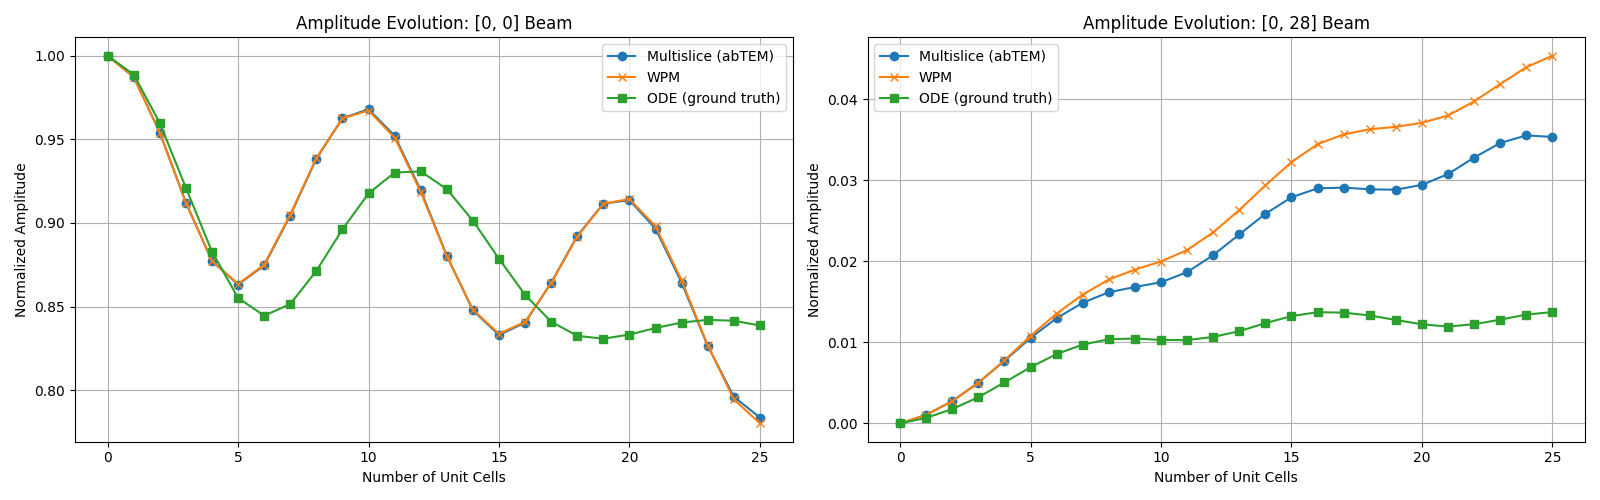

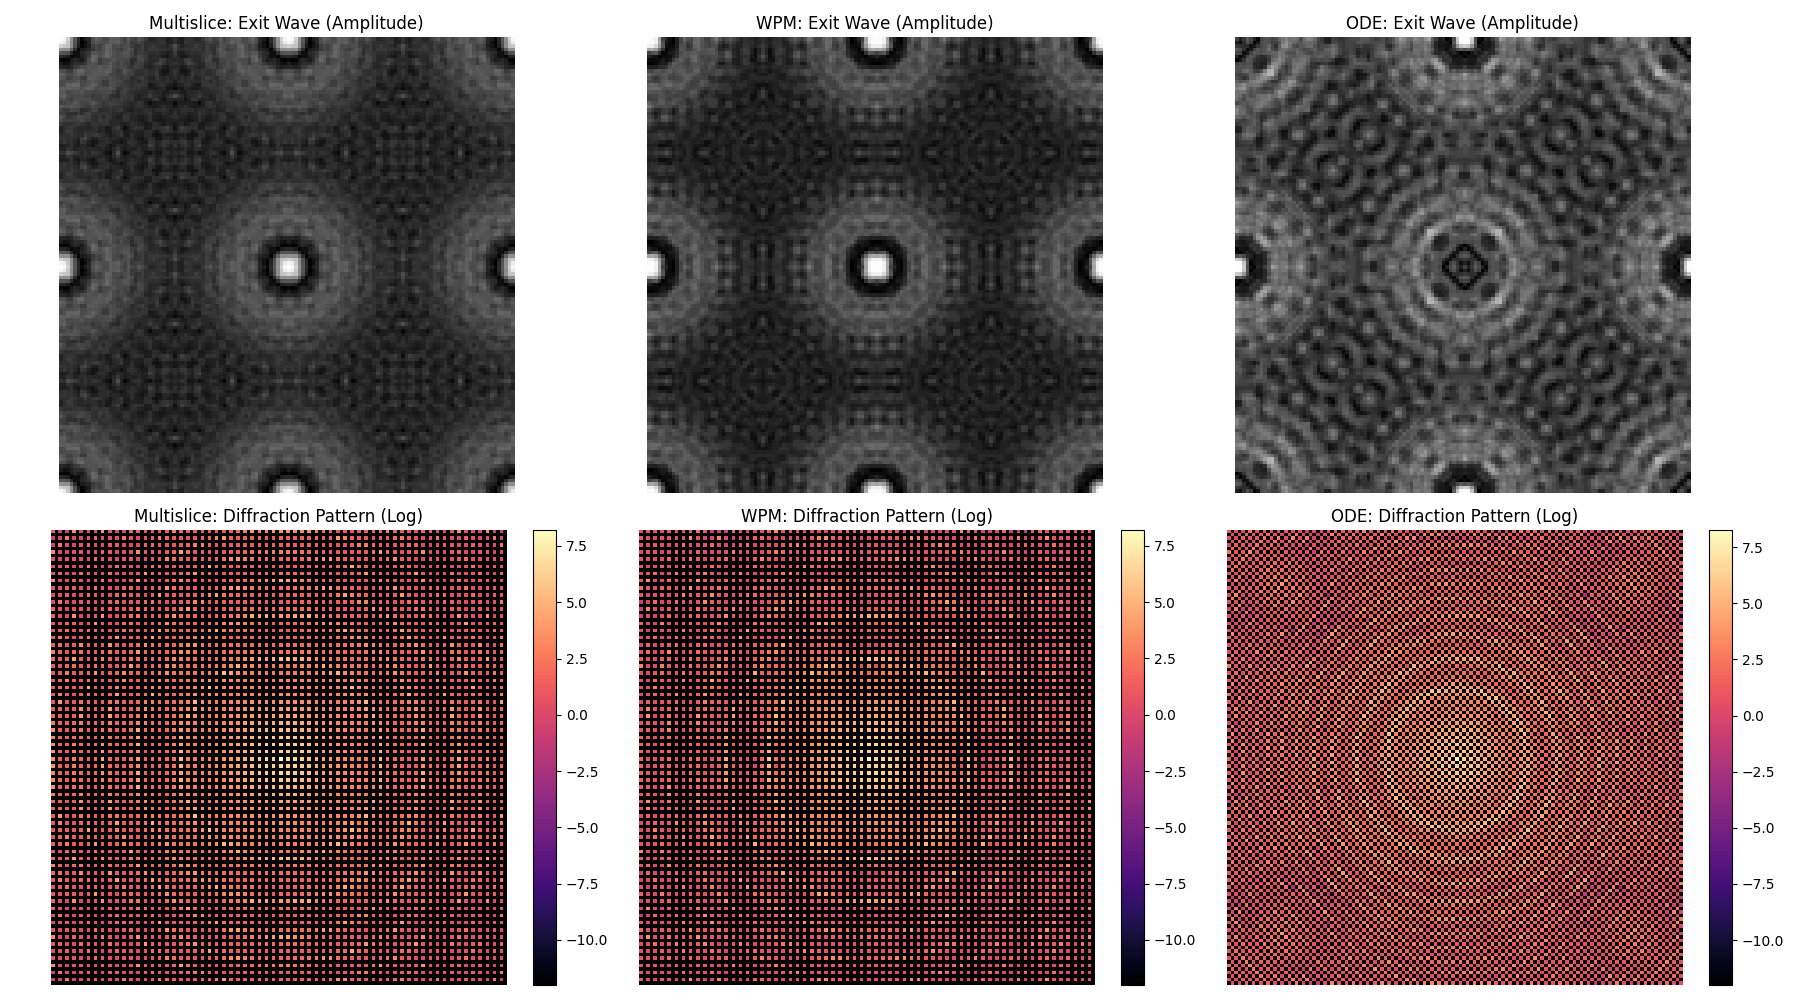

In [22]:
measurements_ODE_0_28 = np.array(measurements_ODE_0_28)
measurements_ODE_0_0 = np.array(measurements_ODE_0_0)

measurements_multislice_0_0 = np.array(measurements_ms_0_0)
measurements_multislice_0_28 = np.array(measurements_ms_0_28)

measurements_wpm_0_0 = np.array(measurements_wpm_0_0)
measurements_wpm_0_28 = np.array(measurements_wpm_0_28)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot [0,0] beam
ax1.plot(measurements_multislice_0_0, marker="o", label="Multislice (abTEM)")
ax1.plot(measurements_wpm_0_0, marker="x", label="WPM")
ax1.plot(measurements_ODE_0_0, marker="s", label="ODE (ground truth)")
ax1.set_xlabel("Number of Unit Cells")
ax1.set_ylabel("Normalized Amplitude")
ax1.set_title("Amplitude Evolution: [0, 0] Beam")
ax1.grid(True)
ax1.legend()

# Plot [0,28] beam
ax2.plot(measurements_multislice_0_28, marker="o", label="Multislice (abTEM)")
ax2.plot(measurements_wpm_0_28, marker="x", label="WPM")
ax2.plot(measurements_ODE_0_28, marker="s", label="ODE (ground truth)")
ax2.set_xlabel("Number of Unit Cells")
ax2.set_ylabel("Normalized Amplitude")
ax2.set_title("Amplitude Evolution: [0, 28] Beam")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Multislice (abTEM) ---
ms_wave = exit_wave_ms
ms_ft = np.fft.fftshift(np.fft.fft2(ms_wave))
ms_log_int = np.log10(np.abs(ms_ft)**2 + 1e-12)

axes[0, 0].imshow(np.abs(ms_wave), cmap="gray")
axes[0, 0].set_title("Multislice: Exit Wave (Amplitude)")
axes[0, 0].axis("off")

im1 = axes[1, 0].imshow(ms_log_int, cmap="magma")
axes[1, 0].set_title("Multislice: Diffraction Pattern (Log)")
axes[1, 0].axis("off")
fig.colorbar(im1, ax=axes[1, 0], fraction=0.046)

# --- WPM ---
wpm_wave = np.array(exit_wave_wpm)
wpm_ft = np.fft.fftshift(np.fft.fft2(wpm_wave))
wpm_log_int = np.log10(np.abs(wpm_ft)**2 + 1e-12)

axes[0, 1].imshow(np.abs(wpm_wave), cmap="gray")
axes[0, 1].set_title("WPM: Exit Wave (Amplitude)")
axes[0, 1].axis("off")

im2 = axes[1, 1].imshow(wpm_log_int, cmap="magma")
axes[1, 1].set_title("WPM: Diffraction Pattern (Log)")
axes[1, 1].axis("off")
fig.colorbar(im2, ax=axes[1, 1], fraction=0.046)

# --- ODE ODE ---
ODE_wave = np.array(exit_wave_ODE)
ODE_ft = np.fft.fftshift(np.fft.fft2(ODE_wave))
ODE_log_int = np.log10(np.abs(ODE_ft)**2 + 1e-12)

axes[0, 2].imshow(np.abs(ODE_wave), cmap="gray")
axes[0, 2].set_title("ODE: Exit Wave (Amplitude)")
axes[0, 2].axis("off")

im3 = axes[1, 2].imshow(ODE_log_int, cmap="magma")
axes[1, 2].set_title("ODE: Diffraction Pattern (Log)")
axes[1, 2].axis("off")
fig.colorbar(im3, ax=axes[1, 2], fraction=0.046)

plt.tight_layout()
plt.show()


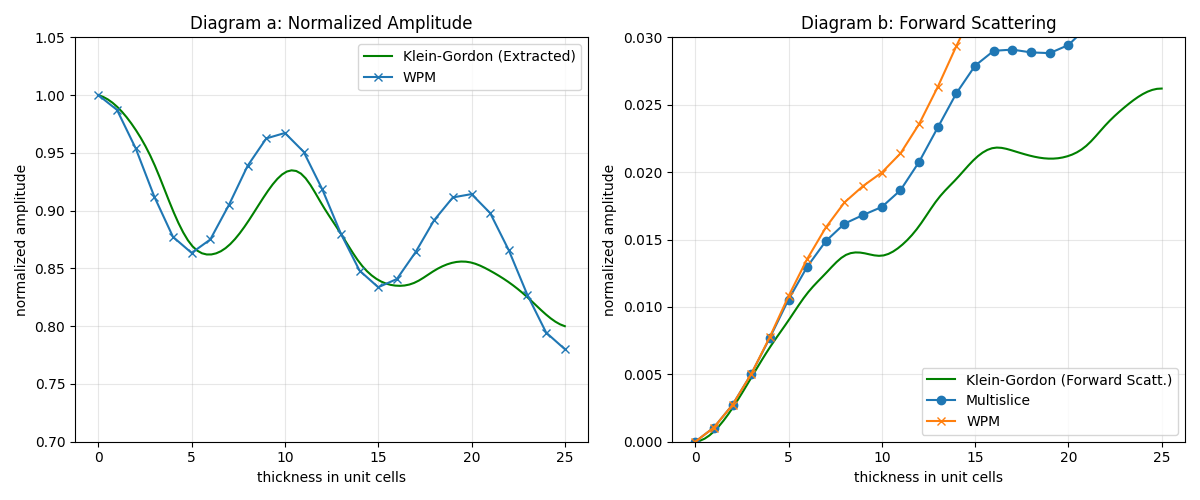

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# --- Data Extraction ---

# Diagram (a): Au [100] Normalized Amplitude vs Thickness
# Since Dirac, KG, and Schrodinger overlap heavily here, 
# this represents the main oscillation path.
x_a = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 
                11, 12, 13, 14, 15, 16, 17, 18, 19, 
                20, 21, 22, 23, 24, 25])

y_a_klein_gordon = np.array([
    1.000, 0.990, 0.970, 0.940, 0.900, 0.870, 0.862, 0.870, 
    0.890, 0.915, 0.933, 0.930, 0.905, 0.880, 0.855, 0.840, 
    0.835, 0.838, 0.848, 0.855, 0.855, 0.848, 0.838, 0.825, 
    0.810, 0.800
])

# Diagram (b): Au [100] Normalized Amplitude vs Thickness (Forward Scattering)
# This corresponds to the UPPER branch labeled "Forward scattering".
# The Green (KG) curve tracks closely with the Red (Dirac) curve here.
x_b = np.array([0, 2, 4, 5, 6, 7, 8, 9, 10, 
                11, 12, 13, 14, 15, 16, 17, 18, 19, 
                20, 21, 22, 23, 24, 25])

y_b_klein_gordon = np.array([
    0.000, 0.0025, 0.0070, 0.0090, 0.0110, 0.0125, 0.0138, 0.0140, 0.0138,
    0.0145, 0.0160, 0.0180, 0.0195, 0.0210, 0.0218, 0.0216, 0.0212, 0.0210, 
    0.0212, 0.0220, 0.0235, 0.0248, 0.0258, 0.0262
])

# --- Plotting to Verify ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot A
# Using cubic interpolation to smooth the lines between sampled points
f_a = interp1d(x_a, y_a_klein_gordon, kind='cubic')
x_new_a = np.linspace(0, 25, 100)

ax1.plot(x_new_a, f_a(x_new_a), 'g-', label='Klein-Gordon (Extracted)')
ax1.plot(x_a, measurements_wpm_0_0, marker="x", label="WPM")
ax1.set_title('Diagram a: Normalized Amplitude')
ax1.set_xlabel('thickness in unit cells')
ax1.set_ylabel('normalized amplitude')
ax1.set_ylim(0.7, 1.05)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot B
f_b = interp1d(x_b, y_b_klein_gordon, kind='cubic')
x_new_b = np.linspace(0, 25, 100)

ax2.plot(x_new_b, f_b(x_new_b), 'g-', label='Klein-Gordon (Forward Scatt.)')
ax2.plot(x_a, measurements_ms_0_28, marker="o", label="Multislice")
ax2.plot(x_a, measurements_wpm_0_28, marker="x", label="WPM")
ax2.set_title('Diagram b: Forward Scattering')
ax2.set_xlabel('thickness in unit cells')
ax2.set_ylabel('normalized amplitude')
ax2.set_ylim(0, 0.03)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()